In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import pandas as pd

In [3]:
archived_flights_legacy = pd.read_csv('/content/drive/MyDrive/Indigo Project/Raw Data/archived_flights_legacy.csv')

In [4]:
competitor_incidents = pd.read_json('/content/drive/MyDrive/Indigo Project/Raw Data/competitor_incidents.json')

In [5]:
competitor_flights = pd.read_csv('/content/drive/MyDrive/Indigo Project/Raw Data/competitor_flights_Q4.csv')

In [6]:
crew_duty_logs_nov = pd.read_csv('/content/drive/MyDrive/Indigo Project/Raw Data/crew_duty_logs_nov.csv')

crew_duty_logs_dec = pd.read_csv('/content/drive/MyDrive/Indigo Project/Raw Data/crew_duty_logs_dec.csv')

dgca_penalty_log = pd.read_csv('/content/drive/MyDrive/Indigo Project/Raw Data/dgca_penalty_log.csv')


In [7]:
pilot_roster_nov = pd.read_json('/content/drive/MyDrive/Indigo Project/Raw Data/pilot_roster_nov.json')

pilot_roster_dec = pd.read_json('/content/drive/MyDrive/Indigo Project/Raw Data/pilot_roster_dec.json')

indigo_flights_nov2025 = pd.read_csv('/content/drive/MyDrive/Indigo Project/Raw Data/indigo_flights_nov2025.csv')

indigo_flights_dec2025 = pd.read_csv('/content/drive/MyDrive/Indigo Project/Raw Data/indigo_flights_dec2025.csv')

fdtl_compliance_report = pd.read_json('/content/drive/MyDrive/Indigo Project/Raw Data/fdtl_compliance_report.json')


In [8]:
revenue_per_route_nov = pd.read_csv('/content/drive/MyDrive/Indigo Project/Raw Data/revenue_per_route_nov.csv')

revenue_per_route_dec = pd.read_csv('/content/drive/MyDrive/Indigo Project/Raw Data/revenue_per_route_dec.csv')

weather_metar_mumbai = pd.read_json('/content/drive/MyDrive/Indigo Project/Raw Data/weather_metar_mumbai.json')

weather_metar_delhi = pd.read_json('/content/drive/MyDrive/Indigo Project/Raw Data/weather_metar_delhi.json')

In [9]:
import pandas as pd

In [ ]:
datasets = {
    "archived_flights_legacy": archived_flights_legacy,
    "competitor_incidents": competitor_incidents,
    "competitor_flights": competitor_flights,
    "crew_duty_logs_nov": crew_duty_logs_nov,
    "crew_duty_logs_dec": crew_duty_logs_dec,
    "dgca_penalty_log": dgca_penalty_log,
    "pilot_roster_nov": pilot_roster_nov,
    "pilot_roster_dec": pilot_roster_dec,
    "indigo_flights_nov2025": indigo_flights_nov2025,
    "indigo_flights_dec2025": indigo_flights_dec2025,
    "fdtl_compliance_report": fdtl_compliance_report,
    "revenue_per_route_nov": revenue_per_route_nov,
    "revenue_per_route_dec": revenue_per_route_dec,
    "weather_metar_mumbai": weather_metar_mumbai,
    "weather_metar_delhi": weather_metar_delhi
}

In [ ]:
for name, df in datasets.items():
    print("=" * 80)
    print(f"Dataset: {name}")
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")
    print("\nColumn Names:")
    print(df.columns.tolist())
    print("\nData Types:")
    print(df.dtypes)
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\n")

Dataset: archived_flights_legacy
Rows: 1488
Columns: 11

Column Names:
['flt_no', 'src', 'dst', 'sched_time', 'actual_time', 'status_cd', 'delay_mins', 'ac_reg', 'sector', 'ops_month', 'data_ver']

Data Types:
flt_no          object
src             object
dst             object
sched_time      object
actual_time     object
status_cd       object
delay_mins     float64
ac_reg          object
sector          object
ops_month       object
data_ver        object
dtype: object

Missing Values:
flt_no           0
src              0
dst              0
sched_time       0
actual_time    234
status_cd        0
delay_mins     234
ac_reg           0
sector           0
ops_month        0
data_ver         0
dtype: int64


Dataset: competitor_incidents
Rows: 2000
Columns: 1

Column Names:
['records']

Data Types:
records    object
dtype: object

Missing Values:
records    0
dtype: int64


Dataset: competitor_flights
Rows: 2928
Columns: 15

Column Names:
['flight_id', 'flight_number', 'airline_name', 

In [ ]:
archived_flights_legacy.rename(columns={
    'flt_no':'flight_number',
    'src':'origin',
    'dst':'destination',
    'sched_time':'scheduled_dep',
    'actual_time':'actual_dep',
    'status_cd':'status',
    'delay_mins':'delay_minutes',
    'ac_reg':'tail_number'
}, inplace=True)

In [ ]:
archived_flights_legacy.columns

Index(['flight_number', 'origin', 'destination', 'scheduled_dep', 'actual_dep',
       'status', 'delay_minutes', 'tail_number', 'sector', 'ops_month',
       'data_ver'],
      dtype='object')

In [ ]:
archived_flights_legacy['scheduled_dep'] = pd.to_datetime(
    archived_flights_legacy['scheduled_dep'],
    dayfirst=True,
    errors='coerce'
)

archived_flights_legacy['actual_dep'] = pd.to_datetime(
    archived_flights_legacy['actual_dep'],
    dayfirst=True,
    errors='coerce'
)

In [ ]:
archived_flights_legacy[['scheduled_dep', 'actual_dep']].head()

,scheduled_dep,actual_dep
0,2025-10-01 03:15:00,2025-10-01 03:15:00
1,2025-10-01 07:30:00,2025-10-01 09:23:00
2,2025-10-01 16:45:00,NaT
3,2025-10-01 00:30:00,2025-10-01 00:30:00
4,2025-10-01 07:15:00,2025-10-01 07:15:00


In [ ]:
archived_flights_legacy[['scheduled_dep', 'actual_dep']].isnull().sum()

,0
scheduled_dep,0
actual_dep,234


In [ ]:
archived_flights_legacy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1488 entries, 0 to 1487
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   flight_number  1488 non-null   object        
 1   origin         1488 non-null   object        
 2   destination    1488 non-null   object        
 3   scheduled_dep  1488 non-null   datetime64[ns]
 4   actual_dep     1254 non-null   datetime64[ns]
 5   status         1488 non-null   object        
 6   delay_minutes  1254 non-null   float64       
 7   tail_number    1488 non-null   object        
 8   sector         1488 non-null   object        
 9   ops_month      1488 non-null   object        
 10  data_ver       1488 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(8)
memory usage: 128.0+ KB


In [ ]:
archived_flights_legacy.to_csv(
    '/content/drive/MyDrive/Indigo Project/Cleaned Data/archived_flights_legacy_clean.csv',
    index=False
)

In [ ]:
indigo_flights_nov2025['scheduled_dep'] = pd.to_datetime(
    indigo_flights_nov2025['scheduled_dep'],
    dayfirst=True,
    errors='coerce'
)

indigo_flights_nov2025['actual_dep'] = pd.to_datetime(
    indigo_flights_nov2025['actual_dep'],
    dayfirst=True,
    errors='coerce'
)

/tmp/ipykernel_889/601906555.py:1: UserWarning: Parsing dates in %Y-%m-%dT%H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  indigo_flights_nov2025['scheduled_dep'] = pd.to_datetime(
/tmp/ipykernel_889/601906555.py:7: UserWarning: Parsing dates in %Y-%m-%dT%H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  indigo_flights_nov2025['actual_dep'] = pd.to_datetime(


In [ ]:
indigo_flights_nov2025.isnull().sum()

,0
flight_id,0
flight_number,0
origin,0
destination,0
scheduled_dep,0
actual_dep,333
status,0
delay_minutes,298
gate,298
tail_number,0


In [ ]:
indigo_flights_nov2025.duplicated().sum()

np.int64(1)

In [ ]:
indigo_flights_nov2025.to_csv(
    '/content/drive/MyDrive/Indigo Project/Cleaned Data/indigo_flights_nov2025_clean.csv',
    index=False
)

In [ ]:
indigo_flights_dec2025['scheduled_dep'] = pd.to_datetime(
    indigo_flights_dec2025['scheduled_dep'],
    dayfirst=True,
    errors='coerce'
)

indigo_flights_dec2025['actual_dep'] = pd.to_datetime(
    indigo_flights_dec2025['actual_dep'],
    dayfirst=True,
    errors='coerce'
)

/tmp/ipykernel_889/2062526556.py:1: UserWarning: Parsing dates in %Y-%m-%dT%H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  indigo_flights_dec2025['scheduled_dep'] = pd.to_datetime(
/tmp/ipykernel_889/2062526556.py:7: UserWarning: Parsing dates in %Y-%m-%dT%H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  indigo_flights_dec2025['actual_dep'] = pd.to_datetime(


In [ ]:
indigo_flights_dec2025.isnull().sum()

,0
flight_id,0
flight_number,0
origin,0
destination,0
scheduled_dep,0
actual_dep,315
status,0
delay_minutes,501
gate,501
tail_number,0


In [ ]:
indigo_flights_dec2025.duplicated().sum()

np.int64(3)

In [ ]:
indigo_flights_dec2025[indigo_flights_dec2025.duplicated()]

,flight_id,flight_number,origin,destination,scheduled_dep,actual_dep,status,delay_minutes,gate,tail_number,passengers,is_night_flight,airline,aircraft_type,source_system
338,100205,6E4509,PAT,COK,2025-12-03 07:15:00,NaT,CANCELLED,NaN,NaN,VT-C037,NaN,0,IndiGo,A321neo,ACARS_v2
1508,100353,6E2059,VNS,LKO,2025-12-06 16:00:00,NaT,CANCELLED,NaN,NaN,VT-A052,NaN,0,IndiGo,A321neo,ACARS_v2
1843,100265,6E8136,BLR,MAA,2025-12-04 00:45:00,NaT,CANCELLED,NaN,NaN,VT-D020,NaN,1,IndiGo,A321,ACARS_v2


In [ ]:
indigo_flights_dec2025[indigo_flights_dec2025.duplicated(keep=False)]

,flight_id,flight_number,origin,destination,scheduled_dep,actual_dep,status,delay_minutes,gate,tail_number,passengers,is_night_flight,airline,aircraft_type,source_system
96,100205,6E4509,PAT,COK,2025-12-03 07:15:00,NaT,CANCELLED,NaN,NaN,VT-C037,NaN,0,IndiGo,A321neo,ACARS_v2
338,100205,6E4509,PAT,COK,2025-12-03 07:15:00,NaT,CANCELLED,NaN,NaN,VT-C037,NaN,0,IndiGo,A321neo,ACARS_v2
582,100353,6E2059,VNS,LKO,2025-12-06 16:00:00,NaT,CANCELLED,NaN,NaN,VT-A052,NaN,0,IndiGo,A321neo,ACARS_v2
889,100265,6E8136,BLR,MAA,2025-12-04 00:45:00,NaT,CANCELLED,NaN,NaN,VT-D020,NaN,1,IndiGo,A321,ACARS_v2
1508,100353,6E2059,VNS,LKO,2025-12-06 16:00:00,NaT,CANCELLED,NaN,NaN,VT-A052,NaN,0,IndiGo,A321neo,ACARS_v2
1843,100265,6E8136,BLR,MAA,2025-12-04 00:45:00,NaT,CANCELLED,NaN,NaN,VT-D020,NaN,1,IndiGo,A321,ACARS_v2


In [ ]:
indigo_flights_dec2025.drop_duplicates(inplace=True)

In [ ]:
indigo_flights_dec2025.duplicated().sum()

np.int64(0)

In [ ]:
indigo_flights_dec2025.to_csv(
    '/content/drive/MyDrive/Indigo Project/Cleaned Data/indigo_flights_dec2025_clean.csv',
    index=False
)

In [ ]:
indigo_flights_nov2025['scheduled_dep'] = pd.to_datetime(
    indigo_flights_nov2025['scheduled_dep'],
    dayfirst=True,
    errors='coerce'
)

indigo_flights_nov2025['actual_dep'] = pd.to_datetime(
    indigo_flights_nov2025['actual_dep'],
    dayfirst=True,
    errors='coerce'
)

/tmp/ipykernel_871/601906555.py:1: UserWarning: Parsing dates in %Y-%m-%dT%H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  indigo_flights_nov2025['scheduled_dep'] = pd.to_datetime(
/tmp/ipykernel_871/601906555.py:7: UserWarning: Parsing dates in %Y-%m-%dT%H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  indigo_flights_nov2025['actual_dep'] = pd.to_datetime(


In [ ]:
indigo_flights_nov2025.isnull().sum()

,0
flight_id,0
flight_number,0
origin,0
destination,0
scheduled_dep,0
actual_dep,333
status,0
delay_minutes,298
gate,298
tail_number,0


In [ ]:
indigo_flights_nov2025.duplicated().sum()

np.int64(0)

In [ ]:
indigo_flights_nov2025[indigo_flights_nov2025.duplicated(keep=False)]

,flight_id,flight_number,origin,destination,scheduled_dep,actual_dep,status,delay_minutes,gate,tail_number,passengers,is_night_flight,airline,aircraft_type,source_system
1406,100212,6E8394,BHO,BLR,2025-11-04 16:30:00,NaT,CANCELLED,NaN,NaN,VT-E037,NaN,0,IndiGo,A321neo,ACARS_v2
1931,100212,6E8394,BHO,BLR,2025-11-04 16:30:00,NaT,CANCELLED,NaN,NaN,VT-E037,NaN,0,IndiGo,A321neo,ACARS_v2


In [ ]:
indigo_flights_nov2025.drop_duplicates(inplace=True)

In [ ]:
indigo_flights_dec2025.groupby('status')[['actual_dep','delay_minutes','gate','passengers']].apply(lambda x: x.isnull().sum())

,actual_dep,delay_minutes,gate,passengers
status,,,,
CANCELLED,295,275,275,275
DELAYED,20,37,37,5
ON_TIME,0,189,189,0


In [ ]:
indigo_flights_nov2025.to_csv(
    '/content/drive/MyDrive/Indigo Project/Cleaned Data/indigo_flights_nov2025_clean.csv',
    index=False
)

In [ ]:
competitor_flights['sched_departure'] = pd.to_datetime(
    competitor_flights['sched_departure'],
    dayfirst=True,
    errors='coerce'
)

competitor_flights['actual_departure'] = pd.to_datetime(
    competitor_flights['actual_departure'],
    dayfirst=True,
    errors='coerce'
)

In [ ]:
competitor_flights.isnull().sum()

,0
flight_id,0
flight_number,0
airline_name,0
iata_code,0
from_airport,0
to_airport,0
sched_departure,1776
actual_departure,1904
flight_status,0
delay_min,350


In [ ]:
competitor_flights.duplicated().sum()

np.int64(0)

In [ ]:
competitor_flights.to_csv(
    '/content/drive/MyDrive/Indigo Project/Cleaned Data/competitor_flights_clean.csv',
    index=False
)

In [ ]:
crew_duty_logs_nov['dep_date'] = pd.to_datetime(
    crew_duty_logs_nov['dep_date'],
    dayfirst=True,
    errors='coerce'
)

In [ ]:
crew_duty_logs_nov.isnull().sum()

,0
employee_id,0
staff_code,0
dep_date,48106
flt_number,4036
sector,0
block_hours,0
rest_hrs_before_duty,0
is_night_duty,0
week_number,0
duty_type,0


In [ ]:
crew_duty_logs_nov.duplicated().sum()

np.int64(0)

In [ ]:
crew_duty_logs_nov[crew_duty_logs_nov.duplicated(keep=False)]

,employee_id,staff_code,dep_date,flt_number,sector,block_hours,rest_hrs_before_duty,is_night_duty,week_number,duty_type,fdtl_rest_required,fdtl_compliant,log_source


In [ ]:
crew_duty_logs_nov.to_csv(
    '/content/drive/MyDrive/Indigo Project/Cleaned Data/crew_duty_logs_nov_clean.csv',
    index=False
)

In [ ]:
crew_duty_logs_dec['dep_date'] = pd.to_datetime(
    crew_duty_logs_dec['dep_date'],
    dayfirst=True,
    errors='coerce'
)

In [ ]:
crew_duty_logs_dec.isnull().sum()

,0
employee_id,0
staff_code,0
dep_date,51042
flt_number,4159
sector,0
block_hours,0
rest_hrs_before_duty,0
is_night_duty,0
week_number,0
duty_type,0


In [ ]:
crew_duty_logs_dec.duplicated().sum()

np.int64(0)

In [ ]:
crew_duty_logs_dec.to_csv(
    '/content/drive/MyDrive/Indigo Project/Cleaned Data/crew_duty_logs_dec_clean.csv',
    index=False
)

In [ ]:
dgca_penalty_log['violation_date'] = pd.to_datetime(
    dgca_penalty_log['violation_date'],
    dayfirst=True,
    errors='coerce'
)

In [ ]:
dgca_penalty_log.isnull().sum()

,0
penalty_id,0
airline,0
violation_type,0
violation_date,200
penalty_inr_lakh,0
daily_fine_inr_lakh,0
compliance_days,0
status,0
dgca_order_ref,0
notes,213


In [ ]:
dgca_penalty_log.duplicated().sum()

np.int64(0)

In [ ]:
dgca_penalty_log.to_csv(
    '/content/drive/MyDrive/Indigo Project/Cleaned Data/dgca_penalty_log_clean.csv',
    index=False
)

In [ ]:
revenue_per_route_nov['date'] = pd.to_datetime(
    revenue_per_route_nov['date'],
    dayfirst=True,
    errors='coerce'
)

In [ ]:
revenue_per_route_nov.isnull().sum()

,0
route_id,0
date,3600
origin,0
destination,0
distance_km,0
avg_fare,0
currency,0
pax_boarded,0
load_factor,0
revenue,0


In [ ]:
revenue_per_route_nov.duplicated().sum()

np.int64(0)

In [ ]:
revenue_per_route_nov.to_csv(
    '/content/drive/MyDrive/Indigo Project/Cleaned Data/revenue_per_route_nov_clean.csv',
    index=False
)

In [ ]:
revenue_per_route_dec['date'] = pd.to_datetime(
    revenue_per_route_dec['date'],
    dayfirst=True,
    errors='coerce'
)

In [ ]:
revenue_per_route_dec.isnull().sum()

,0
route_id,0
date,3800
origin,0
destination,0
distance_km,0
avg_fare,0
currency,0
pax_boarded,0
load_factor,0
revenue,0


In [ ]:
revenue_per_route_dec.duplicated().sum()

np.int64(0)

In [ ]:
revenue_per_route_dec.to_csv(
    '/content/drive/MyDrive/Indigo Project/Cleaned Data/revenue_per_route_dec_clean.csv',
    index=False
)

In [ ]:
pilot_roster_nov.head()

,airline,period,total_pilots,records
0,IndiGo,Nov-2025,4000,"{'pilot_id': 'PIL00001', 'employee_id': 'EMP50..."
1,IndiGo,Nov-2025,4000,"{'pilot_id': 'PIL00002', 'employee_id': 'EMP50..."
2,IndiGo,Nov-2025,4000,"{'pilot_id': 'PIL00003', 'employee_id': 'EMP50..."
3,IndiGo,Nov-2025,4000,"{'pilot_id': 'PIL00004', 'employee_id': 'EMP50..."
4,IndiGo,Nov-2025,4000,"{'pilot_id': 'PIL00005', 'employee_id': 'EMP50..."


In [ ]:
pilot_roster_nov.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   airline       4000 non-null   object
 1   period        4000 non-null   object
 2   total_pilots  4000 non-null   int64 
 3   records       4000 non-null   object
dtypes: int64(1), object(3)
memory usage: 125.1+ KB


In [ ]:
pilot_roster_nov['records'][0]

{'pilot_id': 'PIL00001',
 'employee_id': 'EMP50001',
 'base_station': 'DEL',
 'rank': 'Captain',
 'type_rating': 'A321',
 'duties': [{'date': '2025-11-03',
   'flight_id': '6E6353',
   'origin': 'GOI',
   'destination': 'MAA',
   'departure_time': '2025-11-03T02:15:00',
   'tz': 'IST',
   'block_hours': 5.5,
   'is_night_landing': True,
   'fdtl_compliant': True},
  {'date': '2025-11-04',
   'flight_id': '6E5465',
   'origin': 'HYD',
   'destination': 'IXB',
   'departure_time': '2025-11-04T22:45:00',
   'tz': 'IST',
   'block_hours': 7.7,
   'is_night_landing': False,
   'fdtl_compliant': True},
  {'date': '2025-11-05',
   'flight_id': '6E7476',
   'origin': 'AMD',
   'destination': 'IXB',
   'departure_time': '2025-11-05T11:45:00',
   'tz': 'IST',
   'block_hours': 5.6,
   'is_night_landing': False,
   'fdtl_compliant': True},
  {'date': '2025-11-10',
   'flight_id': '6E8634',
   'origin': 'PAT',
   'destination': 'BLR',
   'departure_time': '2025-11-10T13:00:00',
   'tz': 'IST',
   

In [ ]:
pilot_roster_nov['records'][0]

{'pilot_id': 'PIL00001',
 'employee_id': 'EMP50001',
 'base_station': 'DEL',
 'rank': 'Captain',
 'type_rating': 'A321',
 'duties': [{'date': '2025-11-03',
   'flight_id': '6E6353',
   'origin': 'GOI',
   'destination': 'MAA',
   'departure_time': '2025-11-03T02:15:00',
   'tz': 'IST',
   'block_hours': 5.5,
   'is_night_landing': True,
   'fdtl_compliant': True},
  {'date': '2025-11-04',
   'flight_id': '6E5465',
   'origin': 'HYD',
   'destination': 'IXB',
   'departure_time': '2025-11-04T22:45:00',
   'tz': 'IST',
   'block_hours': 7.7,
   'is_night_landing': False,
   'fdtl_compliant': True},
  {'date': '2025-11-05',
   'flight_id': '6E7476',
   'origin': 'AMD',
   'destination': 'IXB',
   'departure_time': '2025-11-05T11:45:00',
   'tz': 'IST',
   'block_hours': 5.6,
   'is_night_landing': False,
   'fdtl_compliant': True},
  {'date': '2025-11-10',
   'flight_id': '6E8634',
   'origin': 'PAT',
   'destination': 'BLR',
   'departure_time': '2025-11-10T13:00:00',
   'tz': 'IST',
   

## **JSON**

In [ ]:
import pandas as pd

pilot_roster_nov_clean = pd.json_normalize(
    pilot_roster_nov['records'],
    record_path='duties',
    meta=[
        'pilot_id',
        'employee_id',
        'base_station',
        'rank',
        'type_rating',
        ['summary','total_duties'],
        ['summary','avg_weekly_rest_hrs'],
        ['summary','max_night_landings_per_week'],
        ['summary','fdtl_phase']
    ]
)

In [ ]:
pilot_roster_nov_clean.head()

,date,flight_id,origin,destination,departure_time,tz,block_hours,is_night_landing,fdtl_compliant,pilot_id,employee_id,base_station,rank,type_rating,summary.total_duties,summary.avg_weekly_rest_hrs,summary.max_night_landings_per_week,summary.fdtl_phase
0,2025-11-03,6E6353,GOI,MAA,2025-11-03T02:15:00,IST,5.5,True,True,PIL00001,EMP50001,DEL,Captain,A321,17,144.4,2,Phase_I
1,2025-11-04,6E5465,HYD,IXB,2025-11-04T22:45:00,IST,7.7,False,True,PIL00001,EMP50001,DEL,Captain,A321,17,144.4,2,Phase_I
2,2025-11-05,6E7476,AMD,IXB,2025-11-05T11:45:00,IST,5.6,False,True,PIL00001,EMP50001,DEL,Captain,A321,17,144.4,2,Phase_I
3,2025-11-10,6E8634,PAT,BLR,2025-11-10T13:00:00,IST,1.7,False,True,PIL00001,EMP50001,DEL,Captain,A321,17,144.4,2,Phase_I
4,2025-11-11,6E566,IXB,BHO,2025-11-11T10:00:00,IST,8.0,False,True,PIL00001,EMP50001,DEL,Captain,A321,17,144.4,2,Phase_I


In [ ]:
pilot_roster_nov_clean['date'] = pd.to_datetime(
    pilot_roster_nov_clean['date'],
    errors='coerce'
)

pilot_roster_nov_clean['departure_time'] = pd.to_datetime(
    pilot_roster_nov_clean['departure_time'],
    errors='coerce'
)

In [ ]:
pilot_roster_nov_clean.duplicated().sum()

np.int64(0)

In [ ]:
pilot_roster_nov_clean.to_csv(
    '/content/drive/MyDrive/Indigo Project/Cleaned Data/pilot_roster_nov_clean.csv',
    index=False
)

In [ ]:
pilot_roster_dec_clean = pd.json_normalize(
    pilot_roster_dec['records'],
    record_path='duties',
    meta=[
        'pilot_id',
        'employee_id',
        'base_station',
        'rank',
        'type_rating',
        ['summary','total_duties'],
        ['summary','avg_weekly_rest_hrs'],
        ['summary','max_night_landings_per_week'],
        ['summary','fdtl_phase']
    ]
)

In [ ]:
pilot_roster_dec_clean.head()

,date,flight_id,origin,destination,departure_time,tz,block_hours,is_night_landing,fdtl_compliant,pilot_id,employee_id,base_station,rank,type_rating,summary.total_duties,summary.avg_weekly_rest_hrs,summary.max_night_landings_per_week,summary.fdtl_phase
0,2025-12-04,6E5757,JAI,SXR,2025-12-04T17:30:00,IST,3.4,False,True,PIL00001,EMP50001,DEL,Senior First Officer,A320neo,16,152.0,3,Phase_II
1,2025-12-05,6E7109,HYD,BHO,2025-12-05T16:15:00,IST,1.3,False,True,PIL00001,EMP50001,DEL,Senior First Officer,A320neo,16,152.0,3,Phase_II
2,2025-12-06,6E5324,MAA,BLR,2025-12-06T06:45:00,IST,4.3,False,True,PIL00001,EMP50001,DEL,Senior First Officer,A320neo,16,152.0,3,Phase_II
3,2025-12-07,6E2540,IXB,PAT,2025-12-07T10:00:00Z,UTC,2.5,False,True,PIL00001,EMP50001,DEL,Senior First Officer,A320neo,16,152.0,3,Phase_II
4,2025-12-11,6E2114,BOM,HYD,2025-12-11T11:30:00Z,UTC,8.3,False,True,PIL00001,EMP50001,DEL,Senior First Officer,A320neo,16,152.0,3,Phase_II


In [ ]:
pilot_roster_dec_clean['date'] = pd.to_datetime(
    pilot_roster_dec_clean['date'],
    errors='coerce'
)

pilot_roster_dec_clean['departure_time'] = pd.to_datetime(
    pilot_roster_dec_clean['departure_time'],
    errors='coerce'
)

In [ ]:
pilot_roster_dec_clean.duplicated().sum()

np.int64(0)

In [ ]:
pilot_roster_dec_clean.to_csv(
    '/content/drive/MyDrive/Indigo Project/Cleaned Data/pilot_roster_dec_clean.csv',
    index=False
)

In [ ]:
fdtl_compliance_report['records'][0]

{'staff_code': 'SC10001',
 'week_number': 44,
 'year': 2025,
 'fdtl_phase': 'Phase_I',
 'night_landings': 2,
 'night_landing_limit': 6,
 'actual_rest_hrs': 28.5,
 'required_rest_hrs': 36,
 'compliant': 'NO',
 'reported_by': 'Manual Entry',
 'verified': False}

In [ ]:
fdtl_compliance_clean = pd.json_normalize(fdtl_compliance_report['records'])

In [ ]:
fdtl_compliance_clean.head()

,staff_code,week_number,year,fdtl_phase,night_landings,night_landing_limit,actual_rest_hrs,required_rest_hrs,compliant,reported_by,verified
0,SC10001,44,2025,Phase_I,2,6,28.5,36,NO,Manual Entry,False
1,SC10001,45,2025,Phase_II,6,2,29.6,48,NO,Manual Entry,False
2,SC10001,46,2025,Phase_II,4,2,57.8,48,NO,Ops Control,None
3,SC10001,47,2025,Phase_II,4,2,35.1,48,NO,Manual Entry,True
4,SC10001,48,2025,Phase_II,4,2,37.1,48,NO,Manual Entry,False


In [ ]:
fdtl_compliance_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   staff_code           28000 non-null  object 
 1   week_number          28000 non-null  int64  
 2   year                 28000 non-null  int64  
 3   fdtl_phase           28000 non-null  object 
 4   night_landings       28000 non-null  int64  
 5   night_landing_limit  28000 non-null  int64  
 6   actual_rest_hrs      28000 non-null  float64
 7   required_rest_hrs    28000 non-null  int64  
 8   compliant            28000 non-null  object 
 9   reported_by          28000 non-null  object 
 10  verified             18685 non-null  object 
dtypes: float64(1), int64(5), object(5)
memory usage: 2.3+ MB


In [ ]:
fdtl_compliance_report.head()

,source,generated,records
0,DGCA_Internal,2025-12-15,"{'staff_code': 'SC10001', 'week_number': 44, '..."
1,DGCA_Internal,2025-12-15,"{'staff_code': 'SC10001', 'week_number': 45, '..."
2,DGCA_Internal,2025-12-15,"{'staff_code': 'SC10001', 'week_number': 46, '..."
3,DGCA_Internal,2025-12-15,"{'staff_code': 'SC10001', 'week_number': 47, '..."
4,DGCA_Internal,2025-12-15,"{'staff_code': 'SC10001', 'week_number': 48, '..."


In [ ]:
fdtl_compliance_report.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   source     28000 non-null  object
 1   generated  28000 non-null  object
 2   records    28000 non-null  object
dtypes: object(3)
memory usage: 656.4+ KB


In [ ]:
fdtl_compliance_report.columns

Index(['source', 'generated', 'records'], dtype='object')

In [ ]:
fdtl_compliance_report.isnull().sum()

,0
source,0
generated,0
records,0


In [ ]:
fdtl_compliance_report.dtypes

,0
source,object
generated,object
records,object


In [ ]:
for col in fdtl_compliance_report.columns:
    print(f"{col}: {type(fdtl_compliance_report[col].iloc[0])}")

source: <class 'str'>
generated: <class 'str'>
records: <class 'dict'>


In [ ]:
for col in fdtl_compliance_report.columns:
    print(f"{col}: {type(fdtl_compliance_report[col].iloc[0])}")

source: <class 'str'>
generated: <class 'str'>
records: <class 'dict'>


In [ ]:
fdtl_compliance_report.duplicated()

TypeError: unhashable type: 'dict'

In [ ]:
fdtl_compliance_clean = pd.concat(
    [
        fdtl_compliance_report.drop(columns=['records']),
        fdtl_compliance_report['records'].apply(pd.Series)
    ],
    axis=1
)

In [ ]:
fdtl_compliance_clean.columns

Index(['source', 'generated', 'staff_code', 'week_number', 'year',
       'fdtl_phase', 'night_landings', 'night_landing_limit',
       'actual_rest_hrs', 'required_rest_hrs', 'compliant', 'reported_by',
       'verified'],
      dtype='object')

In [ ]:
fdtl_compliance_clean.duplicated().sum()

np.int64(0)

In [ ]:
fdtl_compliance_report.to_csv(
    '/content/drive/MyDrive/Indigo Project/Cleaned Data/fdtl_compliance_report_clean.csv',
    index=False
)

In [ ]:
competitor_incidents.head()

,records
0,"{'incident_id': 'INC-00001', 'airline': 'AirIn..."
1,"{'incident_id': 'INC-00002', 'airline': 'Spice..."
2,"{'incident_id': 'INC-00003', 'airline': 'AirIn..."
3,"{'incident_id': 'INC-00004', 'airline': 'Akasa..."
4,"{'incident_id': 'INC-00005', 'airline': 'Spice..."


In [ ]:
competitor_incidents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   records  2000 non-null   object
dtypes: object(1)
memory usage: 15.8+ KB


In [ ]:
competitor_incidents.columns

Index(['records'], dtype='object')

In [ ]:
competitor_incidents['records'][0]

{'incident_id': 'INC-00001',
 'airline': 'AirIndia',
 'incident_date': '2025-12-23',
 'incident_type': 'CREW_SHORTAGE',
 'severity': 'CRITICAL',
 'flights_affected': 27,
 'resolution_hrs': 30.1,
 'reported_to_dgca': None,
 'news_coverage': False,
 'source': 'NEWS_SCRAPE'}

In [ ]:
from pprint import pprint

pprint(competitor_incidents.iloc[0]['records'])



{'airline': 'AirIndia',
 'flights_affected': 27,
 'incident_date': '2025-12-23',
 'incident_id': 'INC-00001',
 'incident_type': 'CREW_SHORTAGE',
 'news_coverage': False,
 'reported_to_dgca': None,
 'resolution_hrs': 30.1,
 'severity': 'CRITICAL',
 'source': 'NEWS_SCRAPE'}


In [ ]:
competitor_incidents_clean = pd.json_normalize(competitor_incidents['records'])

In [ ]:
competitor_incidents_clean.head()

,incident_id,airline,incident_date,incident_type,severity,flights_affected,resolution_hrs,reported_to_dgca,news_coverage,source
0,INC-00001,AirIndia,2025-12-23,CREW_SHORTAGE,CRITICAL,27,30.1,None,False,NEWS_SCRAPE
1,INC-00002,SpiceJet,2025-12-12,PASSENGER_COMPLAINT,CRITICAL,31,39.9,True,False,NEWS_SCRAPE
2,INC-00003,AirIndia,2025-11-15,ATC_DELAY,HIGH,24,20.4,True,False,DGCA_FEED
3,INC-00004,AkasaAir,2025-11-13,SLOT_MISS,CRITICAL,42,34.0,None,False,NEWS_SCRAPE
4,INC-00005,SpiceJet,2025-11-11,PASSENGER_COMPLAINT,LOW,43,10.0,None,True,DGCA_FEED


In [ ]:
competitor_incidents_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   incident_id       2000 non-null   object 
 1   airline           2000 non-null   object 
 2   incident_date     2000 non-null   object 
 3   incident_type     2000 non-null   object 
 4   severity          2000 non-null   object 
 5   flights_affected  2000 non-null   int64  
 6   resolution_hrs    2000 non-null   float64
 7   reported_to_dgca  1361 non-null   object 
 8   news_coverage     2000 non-null   bool   
 9   source            2000 non-null   object 
dtypes: bool(1), float64(1), int64(1), object(7)
memory usage: 142.7+ KB


In [ ]:
competitor_incidents_clean['incident_date'] = pd.to_datetime(
    competitor_incidents_clean['incident_date'],
    dayfirst=True,
    errors='coerce'
)

/tmp/ipykernel_871/2886519896.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  competitor_incidents_clean['incident_date'] = pd.to_datetime(


In [ ]:
competitor_incidents_clean.isnull().sum()

,0
incident_id,0
airline,0
incident_date,0
incident_type,0
severity,0
flights_affected,0
resolution_hrs,0
reported_to_dgca,639
news_coverage,0
source,0


In [ ]:
competitor_incidents_clean.duplicated().sum()

np.int64(0)

In [ ]:
competitor_incidents_clean.to_csv(
    '/content/drive/MyDrive/Indigo Project/Cleaned Data/competitor_incidents_clean.csv',
    index=False
)

In [ ]:
weather_metar_delhi['observations'][0]

{'station': 'VIDP',
 'obs_datetime': '2025-11-01T00:00:00',
 'metar_raw': 'VIDP 010000Z 31004KT 9999 NIL ////// Q1013',
 'visibility_m': 9999,
 'weather_code': 'NIL',
 'wind_dir_deg': 310,
 'wind_spd_kt': 4,
 'is_fog': 0,
 'low_vis': 0,
 'temp_c': 20.3,
 'dew_point_c': 17.6,
 'qnh_hpa': 1020,
 'data_source': 'METAR_AUTO'}

In [ ]:
weather_metar_delhi['period'] = pd.to_datetime(
    weather_metar_delhi['period'],
    errors='coerce'
)

In [ ]:
weather_metar_delhi_clean = pd.json_normalize(
    weather_metar_delhi['observations']
)

In [ ]:
weather_metar_delhi_clean.head()

,station,obs_datetime,metar_raw,visibility_m,weather_code,wind_dir_deg,wind_spd_kt,is_fog,low_vis,temp_c,dew_point_c,qnh_hpa,data_source
0,VIDP,2025-11-01T00:00:00,VIDP 010000Z 31004KT 9999 NIL ////// Q1013,9999,NIL,310,4,0,0,20.3,17.6,1020,METAR_AUTO
1,VIDP,2025-11-01T03:00:00,VIDP 010300Z 30007KT 6000 NIL ////// Q1013,6000,NIL,300,7,0,0,12.9,14.5,1020,METAR_AUTO
2,VIDP,2025-11-01T06:00:00,VIDP 010600Z 35006KT 9999 NIL ////// Q1013,9999,NIL,350,6,0,0,17.4,16.8,1021,METAR_AUTO
3,VIDP,2025-11-01T09:00:00,VIDP 010900Z 35017KT 9999 NIL ////// Q1013,9999,NIL,350,17,0,0,15.9,9.1,1023,None
4,VIDP,2025-11-01T12:00:00,VIDP 011200Z 34020KT 9999 NIL ////// Q1013,9999,NIL,340,20,0,0,25.5,13.5,1024,METAR_AUTO


In [ ]:
weather_metar_delhi_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488 entries, 0 to 487
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   station       488 non-null    object 
 1   obs_datetime  488 non-null    object 
 2   metar_raw     488 non-null    object 
 3   visibility_m  488 non-null    int64  
 4   weather_code  488 non-null    object 
 5   wind_dir_deg  488 non-null    int64  
 6   wind_spd_kt   488 non-null    int64  
 7   is_fog        488 non-null    int64  
 8   low_vis       488 non-null    int64  
 9   temp_c        488 non-null    float64
 10  dew_point_c   488 non-null    float64
 11  qnh_hpa       488 non-null    int64  
 12  data_source   438 non-null    object 
dtypes: float64(2), int64(6), object(5)
memory usage: 49.7+ KB


In [ ]:
weather_metar_delhi_clean.duplicated().sum()

np.int64(0)

In [ ]:
weather_metar_delhi_clean.to_csv(
'/content/drive/MyDrive/Indigo Project/Cleaned Data/weather_metar_delhi_clean.csv',
index=False
)

In [ ]:
weather_metar_mumbai.head()

,icao_station,period,observations
0,VABB,Nov-Dec 2025,"{'station': 'VABB', 'obs_datetime': '2025-11-0..."
1,VABB,Nov-Dec 2025,"{'station': 'VABB', 'obs_datetime': '2025-11-0..."
2,VABB,Nov-Dec 2025,"{'station': 'VABB', 'obs_datetime': '2025-11-0..."
3,VABB,Nov-Dec 2025,"{'station': 'VABB', 'obs_datetime': '2025-11-0..."
4,VABB,Nov-Dec 2025,"{'station': 'VABB', 'obs_datetime': '2025-11-0..."


In [ ]:
weather_metar_mumbai.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488 entries, 0 to 487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   icao_station  488 non-null    object
 1   period        488 non-null    object
 2   observations  488 non-null    object
dtypes: object(3)
memory usage: 11.6+ KB


In [ ]:
weather_metar_mumbai_clean = pd.json_normalize(
    weather_metar_mumbai['observations']
)

In [ ]:
weather_metar_mumbai_clean['obs_datetime'] = pd.to_datetime(
    weather_metar_mumbai_clean['obs_datetime'],
    errors='coerce'
)

In [ ]:
weather_metar_mumbai_clean.duplicated().sum()

NameError: name 'weather_metar_mumbai_clean' is not defined

In [ ]:
weather_metar_mumbai_clean.isnull().sum()

,0
station,0
obs_datetime,0
metar_raw,0
visibility_m,0
weather_code,0
wind_dir_deg,0
wind_spd_kt,0
is_fog,0
low_vis,0
temp_c,0


In [ ]:
weather_metar_mumbai_clean.to_csv(
    '/content/drive/MyDrive/Indigo Project/Cleaned Data/weather_metar_mumbai_clean.csv',
    index=False
)

In [ ]:
import matplotlib.pyplot as plt

status_count = indigo_flights_dec2025_clean['status'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(status_count.index, status_count.values)
plt.title("Flight Status Distribution")
plt.xlabel("Flight Status")
plt.ylabel("Number of Flights")
plt.grid(axis='y')
plt.show()

NameError: name 'indigo_flights_dec2025_clean' is not defined

In [10]:
indigo_flights_dec2025.columns.tolist()

['flight_id',
 'flight_number',
 'origin',
 'destination',
 'scheduled_dep',
 'actual_dep',
 'status',
 'delay_minutes',
 'gate',
 'tail_number',
 'passengers',
 'is_night_flight',
 'airline',
 'aircraft_type',
 'source_system']

In [11]:
revenue_per_route_dec.columns.tolist()

['route_id',
 'date',
 'origin',
 'destination',
 'distance_km',
 'avg_fare',
 'currency',
 'pax_boarded',
 'load_factor',
 'revenue',
 'refunds_issued',
 'is_govt_capped',
 'cap_fare_limit',
 'season_tag']

In [12]:
crew_duty_logs_dec.columns.tolist()

['employee_id',
 'staff_code',
 'dep_date',
 'flt_number',
 'sector',
 'block_hours',
 'rest_hrs_before_duty',
 'is_night_duty',
 'week_number',
 'duty_type',
 'fdtl_rest_required',
 'fdtl_compliant',
 'log_source']

In [13]:
weather_metar_delhi.columns.tolist()

['icao_station', 'period', 'observations']

In [14]:
pilot_roster_dec.columns.tolist()

['airline', 'period', 'total_pilots', 'records']

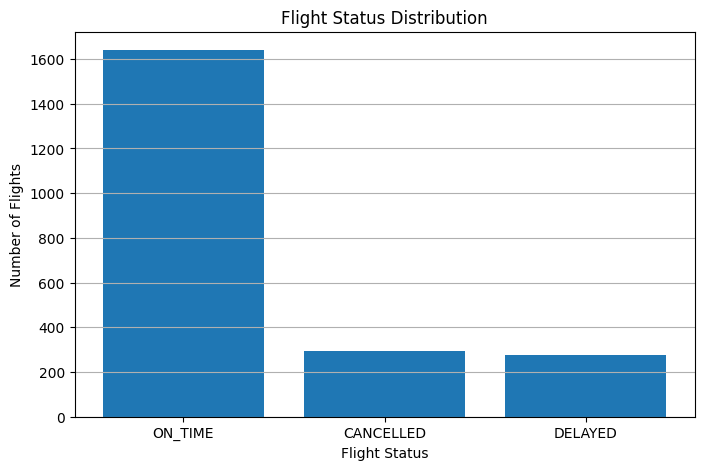

In [15]:
import matplotlib.pyplot as plt

status = indigo_flights_dec2025['status'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(status.index, status.values)
plt.title("Flight Status Distribution")
plt.xlabel("Flight Status")
plt.ylabel("Number of Flights")
plt.grid(axis='y')
plt.show()

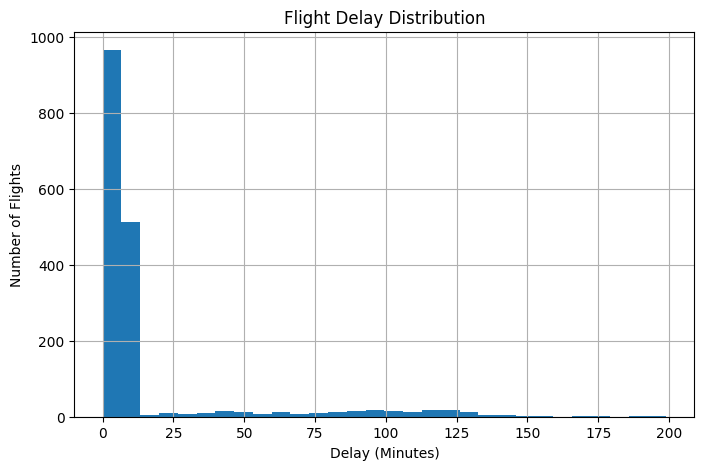

In [16]:
plt.figure(figsize=(8,5))
plt.hist(indigo_flights_dec2025['delay_minutes'].dropna(), bins=30)
plt.title("Flight Delay Distribution")
plt.xlabel("Delay (Minutes)")
plt.ylabel("Number of Flights")
plt.grid(True)
plt.show()

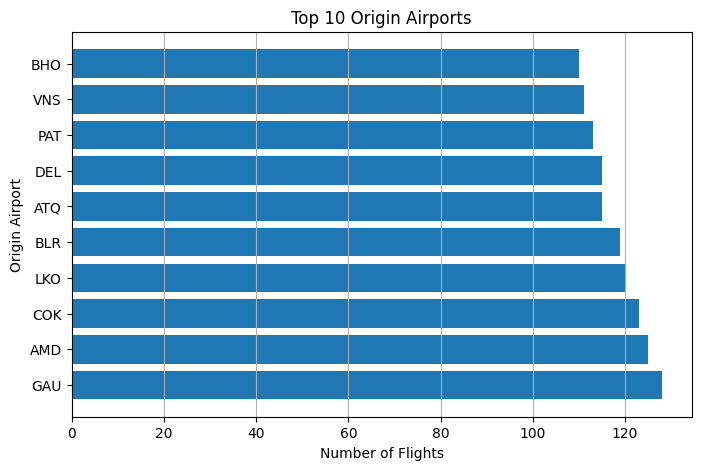

In [17]:
top_origin = indigo_flights_dec2025['origin'].value_counts().head(10)

plt.figure(figsize=(8,5))
plt.barh(top_origin.index, top_origin.values)
plt.title("Top 10 Origin Airports")
plt.xlabel("Number of Flights")
plt.ylabel("Origin Airport")
plt.grid(axis='x')
plt.show()

In [18]:
indigo_flights_dec2025['scheduled_dep'] = pd.to_datetime(
    indigo_flights_dec2025['scheduled_dep'],
    dayfirst=True
)

/tmp/ipykernel_638/2848161122.py:1: UserWarning: Parsing dates in %Y-%m-%dT%H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  indigo_flights_dec2025['scheduled_dep'] = pd.to_datetime(


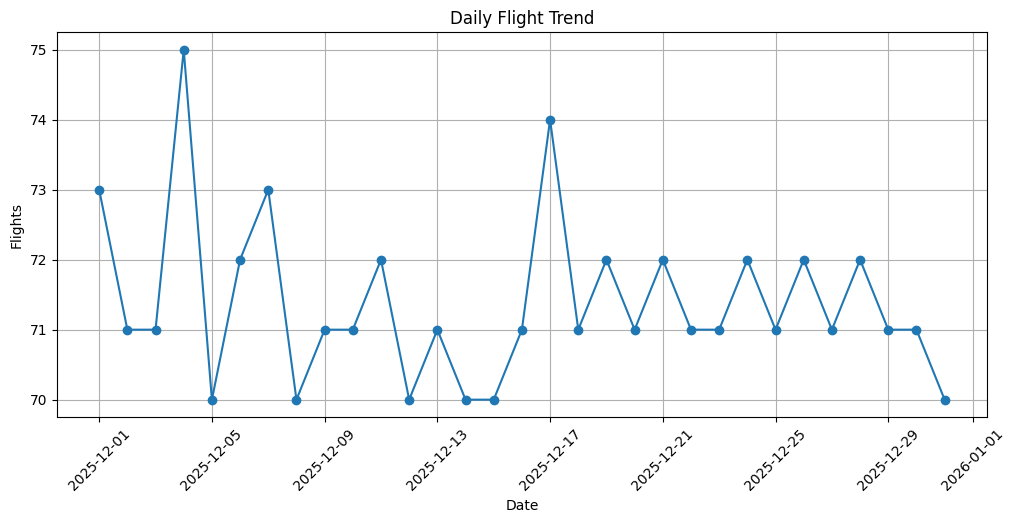

In [19]:
daily = indigo_flights_dec2025.groupby(
    indigo_flights_dec2025['scheduled_dep'].dt.date
).size()

plt.figure(figsize=(12,5))
plt.plot(daily.index, daily.values, marker='o')
plt.title("Daily Flight Trend")
plt.xlabel("Date")
plt.ylabel("Flights")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

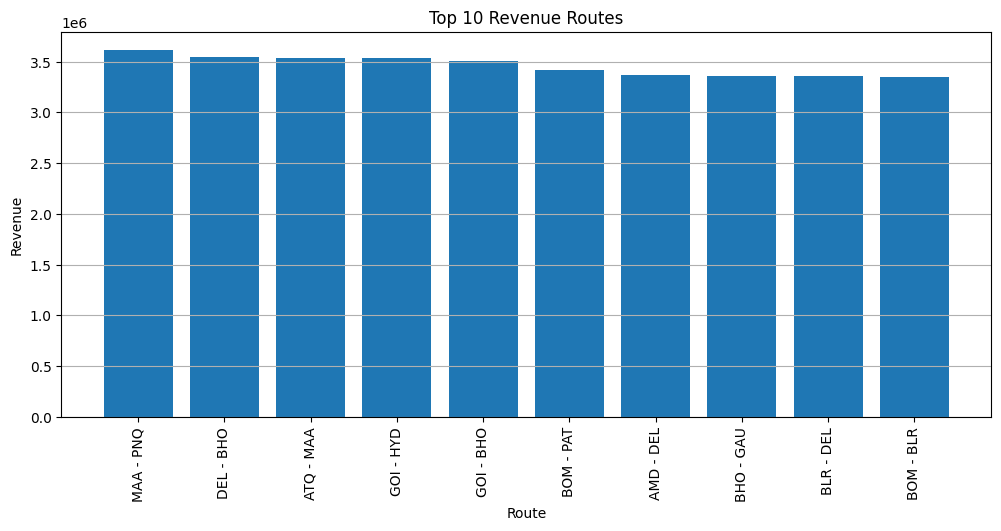

In [20]:
revenue_per_route_dec['Route'] = (
    revenue_per_route_dec['origin'] + " - " +
    revenue_per_route_dec['destination']
)

top_route = revenue_per_route_dec.sort_values(
    'revenue',
    ascending=False
).head(10)

plt.figure(figsize=(12,5))
plt.bar(top_route['Route'], top_route['revenue'])
plt.title("Top 10 Revenue Routes")
plt.xlabel("Route")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.show()

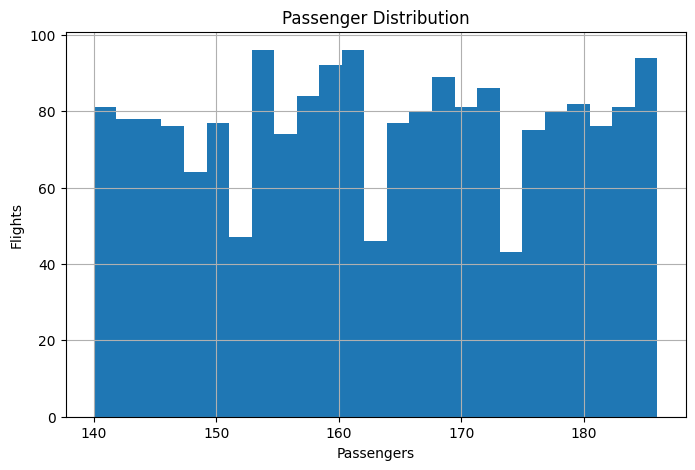

In [21]:
plt.figure(figsize=(8,5))
plt.hist(indigo_flights_dec2025['passengers'], bins=25)
plt.title("Passenger Distribution")
plt.xlabel("Passengers")
plt.ylabel("Flights")
plt.grid(True)
plt.show()

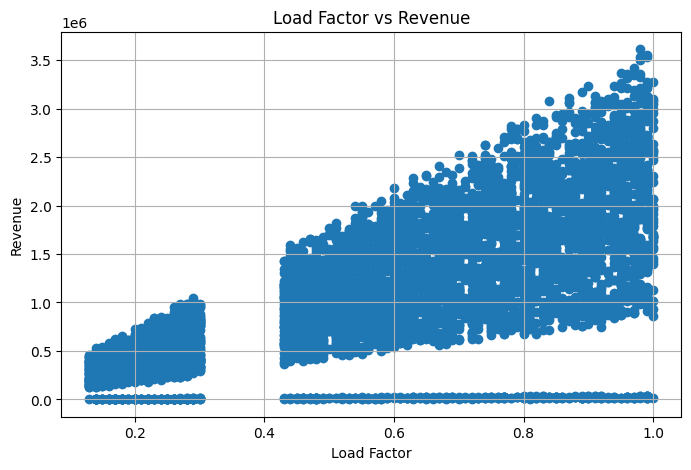

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(
    revenue_per_route_dec['load_factor'],
    revenue_per_route_dec['revenue']
)
plt.title("Load Factor vs Revenue")
plt.xlabel("Load Factor")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

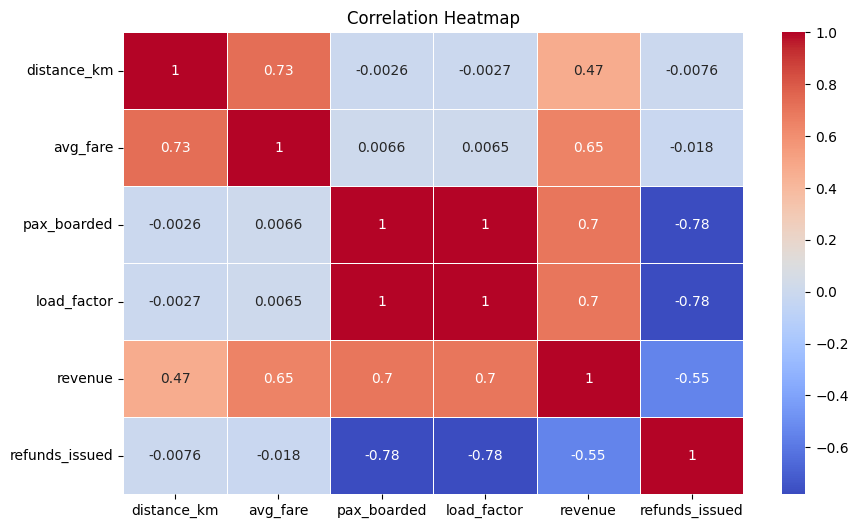

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = revenue_per_route_dec[['distance_km',
                              'avg_fare',
                              'pax_boarded',
                              'load_factor',
                              'revenue',
                              'refunds_issued']].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [26]:
import plotly.express as px
fig = px.treemap(
    revenue_per_route_dec,
    path=['origin','destination'],
    values='revenue'
)

fig.show()

In [27]:
import folium

m = folium.Map(
    location=[22.5,78.9],
    zoom_start=5
)

folium.Marker(
    [28.6139,77.2090],
    popup="Delhi"
).add_to(m)

folium.Marker(
    [19.0760,72.8777],
    popup="Mumbai"
).add_to(m)

folium.Marker(
    [13.0827,80.2707],
    popup="Chennai"
).add_to(m)

m

In [28]:
fig = px.sunburst(
    revenue_per_route_dec,
    path=['origin','destination'],
    values='revenue'
)

fig.show()

In [29]:
x = (1,2,3)
y = (4,5,6)
z = (7,8,9)

In [31]:
px.sunburst(x,y,z)